## Position of a star

### Part 1
Likelihood, MLE estimator 


In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import random
from random import sample
import scipy.stats 

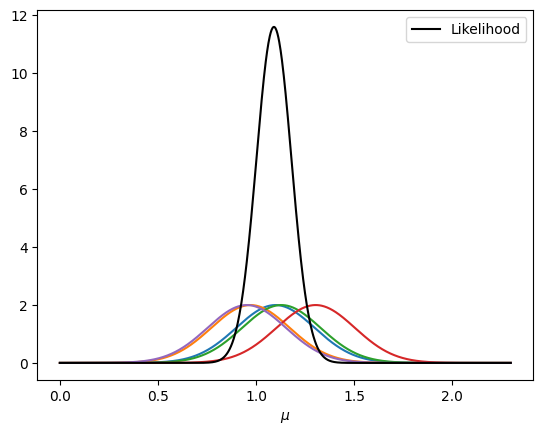

In [3]:
N=5      #number of measurements 

#the underlying process is Gaussian
mu=1
sigma=0.2

np.random.seed(42)
gauss = scipy.stats.norm(loc=mu,scale=sigma)
sample=gauss.rvs(N)                                 #N samples drawn from the Gaussian distribution

x_plot=np.linspace(0,2.3,1000)

L=1

for i in sample:
    distrib=scipy.stats.norm(i,sigma)               #different gaussian centered in the measurements
    plt.plot(x_plot,distrib.pdf(x_plot))
    L*=distrib.pdf(x_plot)


plt.plot(x_plot,L, label="Likelihood", color='black')
plt.xlabel(r"$\mu$")
plt.legend()
plt.show()


In [5]:
max_like=max(L) #maximum likelihood
max_index=np.where(L==max_like) #index of maximum 
max_L=x_plot[max_index] #x of maximum 


print("%0.5f" % np.mean(sample), "is the analytic result of MLE (the mean of the measurements)")
print("%0.5f" % max_L[0], "is the max of likelihood (computed numerically)")

1.09180 is the analytic result of MLE (the mean of the measurements)
1.09129 is the max of likelihood (computed numerically)


### Part 2
Uncertainties of MLE, second order differentiation---- Fisher matrix

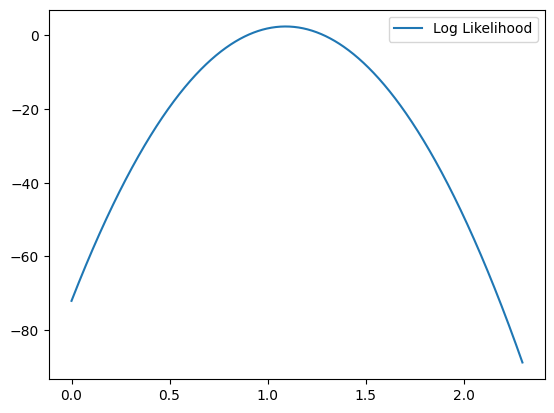

In [7]:
l=np.log(L) #log of likelihood 
plt.plot(x_plot,l, label="Log Likelihood")
plt.legend()
plt.show()

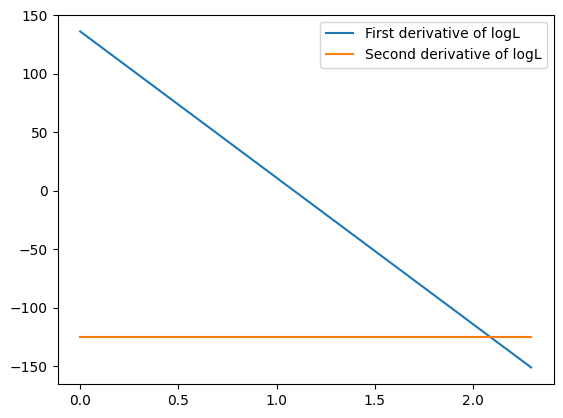

0.08944271909999158832 is the analytical result of the error on mu
0.08944271909997202064 is the numerical result from the Fisher Matrix


In [ ]:
d1=np.diff(l)/np.diff(x_plot) #first derivative: ratio between small increments on y and x 

plt.plot(x_plot[0:len(d1)],d1, label='First derivative of logL') #the length of d1 is one less than the length of the x 

d2=np.diff(d1)/np.diff(x_plot[0:len(d1)]) #second derivative

plt.plot(x_plot[0:len(d2)],d2, label='Second derivative of logL')
plt.legend() 
plt.show()

sigma_mu=(-d2[max_index])**(-0.5)   #result of the Fischer matrix

err_mu_th=sigma/np.sqrt(N)

print("%0.20f" % err_mu_th, "is the analytical result of the error on mu") 
print("%0.20f" % sigma_mu[0], "is the numerical result from the Fisher Matrix")

The difference appears after several decimal digits

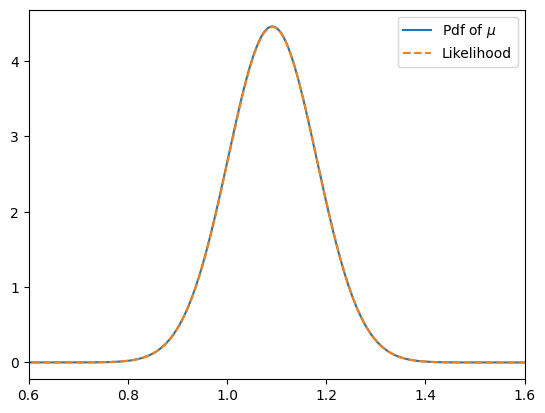

In [186]:
plt.plot(x_plot, scipy.stats.norm.pdf(x_plot, max_L[0], sigma_mu), label=r"Pdf of $\mu$")
plt.plot(x_plot,L/2.6, label="Likelihood", ls='dashed')
plt.xlim(0.6,1.6)
plt.legend()
plt.show()

The product of gaussians (the Likelihood) is still a gaussian with same $\mu$ but $\sigma_{product}=\sigma/\sqrt{N}$ and a different normalization. 

For the normalization we need to expand the quadratic expression at the esponent

In addiction, the MLE is asintotically normal 
 

